In [2]:
import pandas as pd
import seaborn as sns

In [4]:
housePricePrediction=pd.read_csv("HousePricePrediction.csv")
housePricePrediction.sample(5)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
1858,1858,90,RL,7018,Inside,Duplex,5,1979,1979,HdBoard,0.0,0.0,NaN
1586,1586,20,RL,8842,Corner,1Fam,6,1954,1954,VinylSd,0.0,381.0,NaN
1127,1127,20,RL,14572,Corner,1Fam,5,2004,2004,VinylSd,0.0,1530.0,259000.0
2608,2608,60,RL,8286,Corner,1Fam,7,1977,1977,Plywood,0.0,716.0,NaN
2297,2297,20,RL,13615,Corner,1Fam,5,2006,2006,MetalSd,0.0,1802.0,NaN


<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

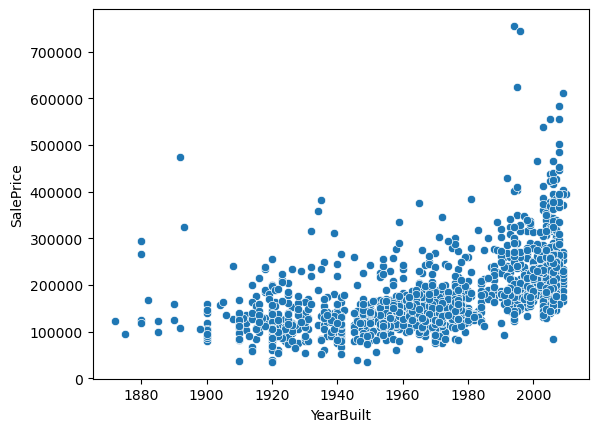

In [5]:
sns.scatterplot(x=housePricePrediction["YearBuilt"], y=housePricePrediction["SalePrice"])

In [6]:
#feature engineering
# housePricePrediction=housePricePrediction.dropna()

X=housePricePrediction.drop(
    columns=["SalePrice"], axis=1
    ).fillna(0)
y=housePricePrediction["SalePrice"].fillna(
    housePricePrediction["SalePrice"].mean()
)

X=pd.get_dummies(X, columns=["MSZoning", "LotConfig", "BldgType", "Exterior1st"], drop_first=False, dtype=int)

In [7]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [8]:
#train model
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
y_pred=model.predict(X_test)
y_pred

array([170098.79443098, 187789.8549534 , 154461.59861516, 188222.91789652,
       201270.28127678, 223166.23809304, 137510.97262808, 201826.35172049,
       131526.98758697, 183943.77307354, 168491.02989181, 188507.79355815,
       181235.13073225, 192553.10554078, 191291.33349711, 195294.22470231,
       163659.60021256, 205104.94278878, 145347.72472653, 172550.69936774,
       208150.17720943, 153222.47996348, 136213.5867454 , 204360.28902283,
       190716.22952841, 197729.84110171, 184807.31914599, 150460.45292922,
       184497.15761776, 165320.91709854, 217472.45450314, 155267.23749183,
       199469.1136688 , 195005.94942292, 195283.50229808, 205483.19918325,
       164783.95903627, 173755.60592643, 159498.07882673, 158587.14158376,
       138493.93847673, 195379.12990983, 216922.04519698, 185082.80680724,
       176131.39806973, 187287.71887934, 188858.45248503, 184182.91720795,
       192735.59999485, 228613.26553289, 153488.83726425, 166104.43541162,
       151292.48149151, 1

In [10]:
y_test

2437    180921.19589
2470    180921.19589
2359    180921.19589
789     187500.00000
1642    180921.19589
            ...     
220     204900.00000
1547    180921.19589
912      88000.00000
449     120000.00000
2378    180921.19589
Name: SalePrice, Length: 876, dtype: float64

In [11]:
#r2-squared evaluation metrics

from sklearn.metrics import r2_score
r2=r2_score(y_test, y_pred)
print("r2_score:", r2)

r2_score: 0.33521674930597467
